# SDM in Python

Some features based on https://github.com/daniel-furman/eco-distribution-mapping/blob/main/Python-sdm.ipynb

### Generate Pseudo-Absence Data
Absence data must be generated for these classifiers, and different quantities must be generated for types of classifiers, based on Barbet-Massin et al., 2012.

### Making subdirectories
inputs - files input for processing   
outputs - results from processing

In [114]:
import os
# os.mkdir("inputs", ex)
# os.mkdir("outputs")
import subprocess
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
# from sklearn.ensemble import ExtraTreesClassifier 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from pygam import LogisticGAM, s, f
from sklearn.tree import DecisionTreeClassifier
# out of all the glms, we choose the poisson - it does not have negative values, and varying variance???
# also we are looking for a scale of values up to 1000...
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from pyimpute import impute
from sklearn import model_selection
from elapid import MaxentModel

import warnings
warnings.filterwarnings('ignore')

In [134]:
files_list = ["nst_pest_sightings\\bean_leaf_beetle_0003221-260623161305970\\0003221-260623161305970.csv", 
              "nst_pest_sightings\\bird_cherry_aphid_0003207-260623161305970\\0003207-260623161305970.csv",
              "nst_pest_sightings\\black_cutworm_0003212-260623161305970\\0003212-260623161305970.csv",
            #   "nst_pest_sightings\\corn_leaf_aphid_0003215-260623161305970\\0003215-260623161305970.csv",
              "nst_pest_sightings\\differential_grasshopper_observations-752834.csv\\observations-752834.csv",
            #   "nst_pest_sightings\\european_corn_borer0003385-260623161305970\\0003385-260623161305970.csv",
              "nst_pest_sightings\\green_stink_0005409-260623161305970\\0005409-260623161305970.csv",
            #   "nst_pest_sightings\\hessian_fly_0003394-260623161305970\\0003394-260623161305970.csv",
              "nst_pest_sightings\\japanese_beetle_0003383-260623161305970\\0003383-260623161305970.csv",
              "nst_pest_sightings\\northern_corn_rootworm_0003360-260623161305970\\0003360-260623161305970.csv",
            #   "nst_pest_sightings\\reg_legged_grasshopperobservations-752840.csv\\observations-752840.csv",
              "nst_pest_sightings\\seedcorn_maggot_0003200-260623161305970\\0001692-260720095953322.csv",
              "nst_pest_sightings\\southern_green_stink_0003348-260623161305970\\0003348-260623161305970.csv",
              "nst_pest_sightings\\three_cornered_alfalfa_0003390-260623161305970\\0003390-260623161305970.csv",
              "nst_pest_sightings\\true_armyworm0032387-260623161305970\\0032387-260623161305970.csv",
            #   "nst_pest_sightings\\two_striped_grasshopper_observations-752841.csv\\observations-752841.csv",
              "nst_pest_sightings\\western_corn_rootworm_0003372-260623161305970\\0003372-260623161305970.csv"
              ]

for file in files_list:
    with open(file, mode='r', encoding='utf-8') as file:
        row_count = sum(1 for line in file)

    print(f"{file}, Total lines: {row_count}")

<_io.TextIOWrapper name='nst_pest_sightings\\bean_leaf_beetle_0003221-260623161305970\\0003221-260623161305970.csv' mode='r' encoding='utf-8'>, Total lines: 849
<_io.TextIOWrapper name='nst_pest_sightings\\bird_cherry_aphid_0003207-260623161305970\\0003207-260623161305970.csv' mode='r' encoding='utf-8'>, Total lines: 882
<_io.TextIOWrapper name='nst_pest_sightings\\black_cutworm_0003212-260623161305970\\0003212-260623161305970.csv' mode='r' encoding='utf-8'>, Total lines: 2273
<_io.TextIOWrapper name='nst_pest_sightings\\differential_grasshopper_observations-752834.csv\\observations-752834.csv' mode='r' encoding='utf-8'>, Total lines: 2125
<_io.TextIOWrapper name='nst_pest_sightings\\green_stink_0005409-260623161305970\\0005409-260623161305970.csv' mode='r' encoding='utf-8'>, Total lines: 7806
<_io.TextIOWrapper name='nst_pest_sightings\\japanese_beetle_0003383-260623161305970\\0003383-260623161305970.csv' mode='r' encoding='utf-8'>, Total lines: 556
<_io.TextIOWrapper name='nst_pest_s

Run the subprocess, R code to generate pseudo absences. Will be customized depending on the models

In [137]:
command_ncr = ["C:\\Users\\chenst-intern\\AppData\\Local\\Programs\\R\\R-4.6.1\\bin\\x64\\Rscript.exe",'pseudo_absence.R', 
           files_list[6], "seedcorn"]

command_tsg = ["C:\\Users\\chenst-intern\\AppData\\Local\\Programs\\R\\R-4.6.1\\bin\\x64\\Rscript.exe",'pseudo_absence.R', 
           'pests\\northern_corn_rootworm_0003360-260623161305970\\ncr.csv', "2", "northerncorn"]
try:
    subprocess.run(command_ncr, capture_output=True, 
        text=True, check = True)
except subprocess.CalledProcessError as e:
    print(f"R Script failed with exit code {e.returncode}")
    print("Error Message:\n", e.stderr)

KeyboardInterrupt: 

### Converting shapefiles (.shp) to geopandas dataframe

In [138]:
import geopandas as gpd
import shutil
import glob

# for f in sorted(glob.glob('data/ncr*')):
#     shutil.copy(f, 'inputs/')

ncr_gdf_mid = gpd.GeoDataFrame.from_file('data/' + command_ncr[3] + '/mid.shp')
ncr_gdf_high = gpd.GeoDataFrame.from_file('data/' + command_ncr[3] + '/high.shp')



Checking duplicates and NA values. Coordinate reference system should ideally be epsg: 4326

In [139]:
print("Number of duplicates: ", ncr_gdf_mid.duplicated(subset='geometry', keep='first').sum())
print("Number of NA's: ", ncr_gdf_mid['geometry'].isna().sum())
print("Coordinate reference system: {}".format(ncr_gdf_mid.crs))
print("{} observations with {} columns".format(*ncr_gdf_mid.shape))

print("Number of duplicates: ", ncr_gdf_high.duplicated(subset='geometry', keep='first').sum())
print("Number of NA's: ", ncr_gdf_high['geometry'].isna().sum())
print("Coordinate reference system: {}".format(ncr_gdf_high.crs))
print("{} observations with {} columns".format(*ncr_gdf_high.shape))

Number of duplicates:  0
Number of NA's:  0
Coordinate reference system: GEOGCS["unknown",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
1999 observations with 2 columns
Number of duplicates:  0
Number of NA's:  0
Coordinate reference system: GEOGCS["unknown",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
10999 observations with 2 columns


Mapping the species presences (pa == 1)

<Axes: >

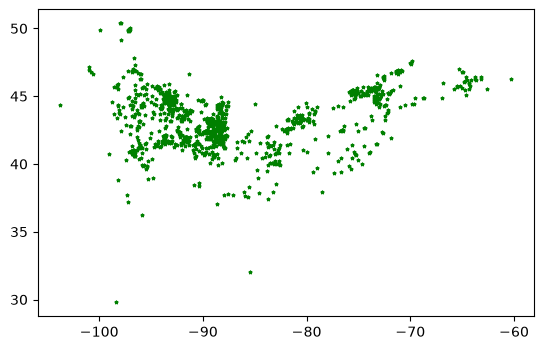

In [140]:
ncr_gdf_mid[ncr_gdf_mid.CLASS == 1].plot(marker='*', color='green', markersize=5)

Mapping the species absences (pa == 0)

<Axes: >

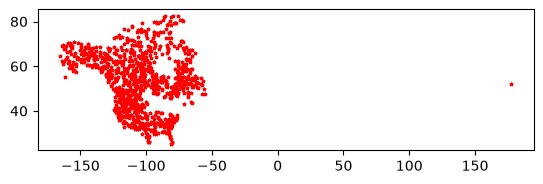

In [141]:
ncr_gdf_mid[ncr_gdf_mid.CLASS == 0].plot(marker='*', color='red', markersize=5)

### Classifier Training

In [188]:
# TO MOVE FILES INTO INPUT
# for f in sorted(glob.glob('worldclim/wc2.1_2.5m_bio_*.tif')):
#     shutil.copy(f,'inputs/')

ras_feats = sorted(glob.glob(
        'chelsa_clim/CHELSA_bio*.tif'))
    # 'worldclim/wc2.1_2.5m_bio_*.tif'))

# THE ORDER IS SIGNIFICANT!!!!

print('There are ', len(ras_feats), ' raster features.')
print(ras_feats)
# current order: 13, 14, 15, 2, 4, 5, 6


There are  7  raster features.
['chelsa_clim\\CHELSA_bio02_1981-2010_V.2.1.tif', 'chelsa_clim\\CHELSA_bio04_1981-2010_V.2.1.tif', 'chelsa_clim\\CHELSA_bio05_1981-2010_V.2.1.tif', 'chelsa_clim\\CHELSA_bio06_1981-2010_V.2.1.tif', 'chelsa_clim\\CHELSA_bio13_1981-2010_V.2.1.tif', 'chelsa_clim\\CHELSA_bio14_1981-2010_V.2.1.tif', 'chelsa_clim\\CHELSA_bio15_1981-2010_V.2.1.tif']


In [160]:
import rasterio

with rasterio.open(ras_feats[0]) as src:
    raster_crs = src.crs

ncr_gdf_mid = ncr_gdf_mid.to_crs(raster_crs)
ncr_gdf_high = ncr_gdf_high.to_crs(raster_crs)

ncr_gdf_low = []
for i in range(1,11):
    ncr_gdf_low.append(gpd.GeoDataFrame.from_file('data/' + command_ncr[3] + '/low/'+ str(i) + '.shp').to_crs(raster_crs))

 
print(ncr_gdf_mid.crs)


GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


In [161]:
ncr_gdf_mid.sample(5)

,CLASS,geometry
920,0.0,POINT (-118.20546 73.0771)
1790,0.0,POINT (-84.99511 53.42746)
864,0.0,POINT (-112.33733 71.57176)
1531,1.0,POINT (-88.9065 43.08604)
887,1.0,POINT (-71.33751 46.83361)


Generate raster maps of suitability. Also separate test sets from the rest for cross validation

In [183]:
from pyimpute import load_training_vector
from pyimpute import load_targets
import numpy as np
import pandas as pd

train_xs_mid, train_ys_mid = load_training_vector(ncr_gdf_mid, ras_feats, response_field='CLASS')

x_df_mid = pd.DataFrame(train_xs_mid)
x_df_mid.columns = ['bio13', 'bio14', 'bio15', 'bio2', 'bio4', 'bio5', 'bio6']
x_df_mid = x_df_mid.apply(pd.to_numeric, errors="coerce")
x_df_mid = x_df_mid.replace([np.inf, -np.inf], np.nan)

y_ser_mid = pd.Series(train_ys_mid)

mask_mid = x_df_mid.notna().all(axis=1) & y_ser_mid.notna()

# Apply mask_mid to both X and y
train_xs_mid_clean = x_df_mid.loc[mask_mid].to_numpy(dtype=float)
train_ys_mid_clean = y_ser_mid.loc[mask_mid].to_numpy()

print("Original samples:", len(train_xs_mid))
print("Clean samples:", len(train_xs_mid_clean))
print("Dropped samples:", len(train_xs_mid) - len(train_xs_mid_clean))


train_x_mid, test_x_mid, train_y_mid, test_y_mid = model_selection.train_test_split(train_xs_mid_clean, train_ys_mid_clean, test_size=0.25, random_state=42, stratify=train_ys_mid_clean)
# train_xs_mid.shape, train_ys_mid.shape
train_x_mid.shape, test_x_mid.shape, train_y_mid.shape, test_y_mid.shape

Original samples: 1999
Clean samples: 1996
Dropped samples: 3


((1497, 7), (499, 7), (1497,), (499,))

In [186]:
x_df_mid.sample(5)

,bio13,bio14,bio15,bio2,bio4,bio5,bio6
254,113.0,15.0,57.686279,11.441999,1205.457275,28.288000,-16.108
1201,101.0,29.0,35.898872,10.779000,1061.211060,27.696001,-12.628
1125,64.0,18.0,40.731174,4.382000,1280.429932,14.360000,-25.916
1802,96.0,54.0,16.788698,9.226334,990.884094,27.112000,-8.844
1381,116.0,32.0,35.458141,11.463667,1075.479492,28.691999,-12.288


          bio13     bio14     bio15      bio2      bio4      bio5      bio6
bio13  1.000000  0.589421 -0.237640  0.025423 -0.517425  0.287724  0.519240
bio14  0.589421  1.000000 -0.821002 -0.089795 -0.466791  0.202549  0.455634
bio15 -0.237640 -0.821002  1.000000 -0.031755  0.399552 -0.296962 -0.433011
bio2   0.025423 -0.089795 -0.031755  1.000000 -0.449213  0.753683  0.555002
bio4  -0.517425 -0.466791  0.399552 -0.449213  1.000000 -0.510950 -0.894414
bio5   0.287724  0.202549 -0.296962  0.753683 -0.510950  1.000000  0.813012
bio6   0.519240  0.455634 -0.433011  0.555002 -0.894414  0.813012  1.000000


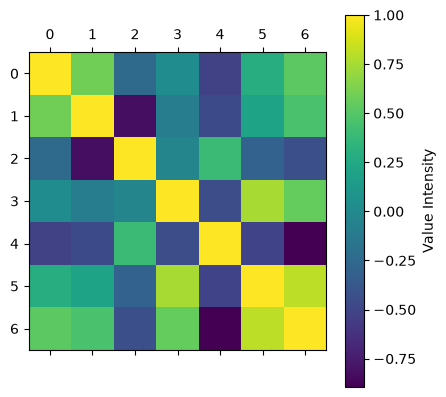

In [187]:
import matplotlib.pyplot as plt
corr = x_df_mid.corr(method="pearson")
print(corr)

plt.matshow(corr)
plt.colorbar(label='Value Intensity')
plt.show()

In [145]:
print(train_x_mid)

[[   71.  6696.  2913. ...  3797.   849.   492.]
 [  117.  9526.  2989. ...   398.    99.   416.]
 [   78.  9811.  3004. ...  1071.   394.   311.]
 ...
 [   97. 10388.  3023. ...  1236.   247.   436.]
 [  101. 10998.  3012. ...  1091.   142.   521.]
 [   73.  9845.  2974. ...  1273.   641.   220.]]


In [146]:
train_xs_high, train_ys_high = load_training_vector(ncr_gdf_high, ras_feats, response_field='CLASS')

x_df_high = pd.DataFrame(train_xs_high)
x_df_high = x_df_high.apply(pd.to_numeric, errors="coerce")
x_df_high = x_df_high.replace([np.inf, -np.inf], np.nan)

y_ser_high = pd.Series(train_ys_high)

mask_high = x_df_high.notna().all(axis=1) & y_ser_high.notna()

# Apply mask_mid to both X and y
train_xs_high_clean = x_df_high.loc[mask_high].to_numpy(dtype=float)
train_ys_high_clean = y_ser_high.loc[mask_high].to_numpy()

print("Original samples:", len(train_xs_high))
print("Clean samples:", len(train_xs_high_clean))
print("Dropped samples:", len(train_xs_high) - len(train_xs_high_clean))


train_x_high, test_x_high, train_y_high, test_y_high = model_selection.train_test_split(train_xs_high_clean, train_ys_high_clean, test_size=0.25, random_state=42, stratify=train_ys_high_clean)
# train_xs_mid.shape, train_ys_mid.shape
train_x_high.shape, test_x_high.shape, train_y_high.shape, test_y_high.shape

Original samples: 10999
Clean samples: 10999
Dropped samples: 0


((8249, 7), (2750, 7), (8249,), (2750,))

Classifier implementation

In [147]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss

sample_weights_mid = compute_sample_weight(class_weight='balanced', y=train_y_mid)
sample_weights_high = compute_sample_weight(class_weight='balanced', y=train_y_high)
k = 10
kf = model_selection.KFold(n_splits=k, shuffle=True, random_state=42)

def make_model_dict(name, model):
    return {
        "name": name,
        "model": model,
        "threshold": -1,
        "auc": -1,
        "maxsss": -1,
        "frozen model": None
    }

rf = make_model_dict("random forest", RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1))

lda = make_model_dict("lda", LinearDiscriminantAnalysis())

dtc = make_model_dict("decision tree", DecisionTreeClassifier(max_depth=3, min_samples_split=5, random_state=42))

lr = make_model_dict("log res glm", LogisticRegression(max_iter = 1000))

lr1 = make_model_dict("log res big", LogisticRegression(max_iter=5000))

xgb = make_model_dict("xg boost", XGBClassifier())

mars_model = make_pipeline(SplineTransformer(degree=1, n_knots=10, include_bias=False), LogisticRegression())
mars = make_model_dict("mars", mars_model)

me = make_model_dict("maxent", MaxentModel())

gam = make_model_dict("log gam", LogisticGAM(s(0) + s(1) + s(2)))

models = [rf, lda, dtc, lr, lr1, xgb, mars, me, gam]

In [148]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.frozen import FrozenEstimator
cand_thresholds = np.linspace(0, 1, 1001)

train_x_models, ensemble_val_x, train_y_models, ensemble_val_y = model_selection.train_test_split(train_x_mid, train_y_mid, test_size=0.2, random_state=42, stratify=train_y_mid)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
# train the model (cross validate)
    thresholds = []
    msss_scores = []
    print(model["name"])
    try:
        cv_score = model_selection.cross_val_score(model["model"], train_x_models, train_y_models, cv=skf)
        print("Cross validation score:", np.mean(cv_score))
    except AttributeError as e:
        print("cross validation score not available for this model.")

    for train_id, val_id in skf.split(train_x_models, train_y_models):
        x_train = train_x_models[train_id]
        x_val = train_x_models[val_id]
        y_train = train_y_models[train_id]
        y_val = train_y_models[val_id]

        model["model"].fit(x_train, y_train)
# calculate probabilities with val data
        try:
            val_prob = model["model"].predict_proba(x_val)[:, 1]
        except IndexError as e:
            val_prob = model["model"].predict_proba(x_val)
# scores = model_selection.cross_val_score(model["model"], train_x_mid, train_y_mid, cv=kf, scoring="")
# calculate threshold

        best_threshold = 0
        best_sum = -1
        # best_sensit = -1
        # best_specif = -1

        for threshold in cand_thresholds:
            val_pred = (val_prob >= threshold).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_val, val_pred, labels=[0, 1]).ravel()

            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
            specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

            sens_spec_sum = sensitivity + specificity

            if sens_spec_sum > best_sum:
                best_sum = sens_spec_sum
                best_threshold = threshold
            # best_sensitivity = sensitivity
            # best_specificity = specificity
    thresholds.append(best_threshold)
    msss_scores.append(best_sum)
    # model["threshold"] = best_threshold
    model["threshold"] = np.mean(thresholds)
    model["maxsss"] = np.mean(msss_scores)
    
    print("Best threshold:", model["threshold"])
    print("Max sensitivity + specificity:", model["maxsss"])
    # print("Sensitivity:", best_sensitivity)
    # print("Specificity:", best_specificity)
    print("Youden J:", model["maxsss"] - 1)
# retrain the model with all training data available
    model["model"].fit(train_x_models, train_y_models)
    model["frozen model"] = FrozenEstimator(model["model"])
    print("model frozen")

    try:
        test_prob = model["model"].predict_proba(test_x_mid)[:, 1]
    except IndexError as e:
        test_prob = model["model"].predict_proba(test_x_mid)

    test_pred = (test_prob >= model["threshold"]).astype(int)

# find auc at the threshold
    auc_score = roc_auc_score(test_y_mid, test_pred)
    model["auc"] = auc_score
    print("AUC score: ", auc_score)

random forest
Cross validation score: 0.9791562064156206
Best threshold: 0.222
Max sensitivity + specificity: 1.975
Youden J: 0.9750000000000001
model frozen
AUC score:  0.968
lda
Cross validation score: 0.8607357043235705
Best threshold: 0.536
Max sensitivity + specificity: 1.7912464985994396
Youden J: 0.7912464985994396
model frozen
AUC score:  0.86
decision tree
Cross validation score: 0.9649755927475594
Best threshold: 0.201
Max sensitivity + specificity: 1.9581932773109243
Youden J: 0.9581932773109243
model frozen
AUC score:  0.964
log res glm
Cross validation score: 0.8849198047419804
Best threshold: 0.47300000000000003
Max sensitivity + specificity: 1.824719887955182
Youden J: 0.824719887955182
model frozen
AUC score:  0.876
log res big
Cross validation score: 0.8849198047419804
Best threshold: 0.47300000000000003
Max sensitivity + specificity: 1.824719887955182
Youden J: 0.824719887955182
model frozen
AUC score:  0.876
xg boost
Cross validation score: 0.9749860529986053
Best th

In [149]:
# ensemble models: find the indices of the dictionary models with the highest auc and tss scores? 
# find the highest auc and tss amongst different groups of classifiers: regressors, 
import heapq

auc_scores = []
tss_scores = []

for model in models:
    auc_scores.append(model["auc"])
    tss_scores.append(model["maxsss"] - 1)

largest_auc = heapq.nlargest(3, range(len(auc_scores)), key=auc_scores.__getitem__)
print(largest_auc)



[5, 6, 0]


Loading future predictions

In [189]:
from pylab import plt
future_stacks = ["worldclim\\future\\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040.tif", "worldclim\\future\\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp245_2021-2040.tif",
                "worldclim\\future\\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp370_2021-2040.tif", "worldclim\\future\\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp585_2021-2040.tif"]
future_40_stacks = ["worldclim\\future40\\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2041-2060.tif", "worldclim\\future40\\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp245_2041-2060.tif", "worldclim\\future40\\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp370_2041-2060.tif",
                    "worldclim\\future40\\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp585_2041-2060.tif"]
out_dir = "future_split_bands"

from rasterio.windows import from_bounds


training_feature_names = [
    "bio2",
    "bio4",
    "bio5",
    "bio6",
    "bio13",
    "bio14",
    "bio15"
]

future_band_map = {
    "bio13": 13,
    "bio14": 14,
    "bio15": 15,
    "bio2": 2,
    "bio4": 4,
    "bio5": 5,
    "bio6": 6
}
min_lon = -170
max_lon = -52
min_lat = 24
max_lat = 83.5

future_ras_feats = []

for index, stack in enumerate(future_40_stacks):
    # os.mkdir(f"{out_dir}_{index}")
    with rasterio.open(stack) as src:
        # print("Band count:", src.count)
        # print("CRS:", src.crs)
        # print("Shape:", src.shape)
        # print("Bounds:", src.bounds)
        # print("Descriptions:", src.descriptions)
        # print("Indexes:", src.indexes)
# with rasterio.open(future_stack) as src:
        window = from_bounds(
                min_lon,
                min_lat,
                max_lon,
                max_lat,
                transform=src.transform
        ).round_offsets().round_lengths()

        data = src.read(1, window=window)

        new_transform = src.window_transform(window)

        profile = src.profile.copy()
        profile.update({
            "height": data.shape[0],
            "width": data.shape[1],
            "transform": new_transform,
            "count": 1
        })
        
        temp_future_ras_feats = []
        for feature_name in training_feature_names:
            
            band_index = future_band_map[feature_name]

            band = src.read(band_index, window=window)

            out_path = os.path.join(f"{out_dir}_{index}", f"future_{feature_name}.tif")
            with rasterio.open(out_path, "w", **profile) as dst:
                dst.write(band, 1)
                dst.set_band_description(1, feature_name)

            temp_future_ras_feats.append(out_path)

    future_ras_feats.append(temp_future_ras_feats)
    # future_ras_feats = sorted(glob.glob(
    #     'future_split_bands_1/future_bio*.tif')) 



In [ ]:
print(future_ras_feats)

[['future_split_bands_0\\future_bio13.tif', 'future_split_bands_0\\future_bio14.tif', 'future_split_bands_0\\future_bio15.tif', 'future_split_bands_0\\future_bio2.tif', 'future_split_bands_0\\future_bio4.tif', 'future_split_bands_0\\future_bio5.tif', 'future_split_bands_0\\future_bio6.tif'], ['future_split_bands_1\\future_bio13.tif', 'future_split_bands_1\\future_bio14.tif', 'future_split_bands_1\\future_bio15.tif', 'future_split_bands_1\\future_bio2.tif', 'future_split_bands_1\\future_bio4.tif', 'future_split_bands_1\\future_bio5.tif', 'future_split_bands_1\\future_bio6.tif'], ['future_split_bands_2\\future_bio13.tif', 'future_split_bands_2\\future_bio14.tif', 'future_split_bands_2\\future_bio15.tif', 'future_split_bands_2\\future_bio2.tif', 'future_split_bands_2\\future_bio4.tif', 'future_split_bands_2\\future_bio5.tif', 'future_split_bands_2\\future_bio6.tif'], ['future_split_bands_3\\future_bio13.tif', 'future_split_bands_3\\future_bio14.tif', 'future_split_bands_3\\future_bio15.ti

In [151]:
from matplotlib.colors import ListedColormap, BoundaryNorm
def plotit(x, title, colors, cmap="Blues"):
    x = np.asarray(x)
    unique_vals = [0, 1, -9999]
    n_val = len(unique_vals)
    base = plt.get_cmap(cmap, n_val)
    plt.imshow(x, cmap=cmap, interpolation='nearest')
    
    x_mapped = np.full(x.shape, np.nan)

    for i, val in enumerate(unique_vals):
        x_mapped[x == val] = i
    
    discrete_cmap = ListedColormap(colors)

    bounds = np.arange(-0.5, n_val + 0.5, 1)
    norm = BoundaryNorm(bounds, discrete_cmap.N)

    im = plt.imshow(
        x_mapped,
        cmap=discrete_cmap,
        norm=norm,
        interpolation="nearest"
    )

    cbar = plt.colorbar(im, ticks=np.arange(n_val))
    cbar.ax.set_yticklabels(unique_vals)

    plt.title(title, fontweight="bold")
    plt.savefig(title, dpi=300, bbox_inches='tight')
    plt.show()

In [152]:
# we use votingclassifier, but since we already have pretrained models, we use frozen classifiers as detailed here:
# https://github.com/scikit-learn/scikit-learn/issues/12297
from sklearn.ensemble import VotingClassifier
ssp = ['126', '245', '370', '585']

future_target_xss = []
future_raster_infos = []

ensemble_models = [(models[x]["name"], models[x]["frozen model"]) for x in largest_auc]

#impute cannot handle nans.............
vc = VotingClassifier(ensemble_models, voting="soft")

# all classifiers are frozen, so fitting has no effect, but is still a required action
vc.fit(train_x_mid, train_y_mid)

best_threshold = 0
best_sum = -1
# best_sensit = -1
# best_specif = -1
vc_val_prob = vc.predict_proba(ensemble_val_x)[:, 1]

for threshold in cand_thresholds:
    vc_val_pred = (vc_val_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(ensemble_val_y, vc_val_pred, labels=[0, 1]).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    sens_spec_sum = sensitivity + specificity

    if sens_spec_sum > best_sum:
        best_sum = sens_spec_sum
        best_threshold = threshold

ensemble_test_prob = vc.predict_proba(test_x_mid)[:, 1]
ensemble_test_pred = (ensemble_test_prob >= best_threshold).astype(int)
ensemble_score = roc_auc_score(test_y_mid, ensemble_test_pred)
print("Ensemble model score: ", ensemble_score)
print("ensemble threshold: ", best_threshold, " ", best_sum)


for index, feat in enumerate(future_ras_feats):
    future_target_xs, future_raster_info = load_targets(feat)
    print(future_raster_info)

    future_target_xs_df = pd.DataFrame(future_target_xs)
    future_target_xs_df.sample(5)
    future_target_xs_df = future_target_xs_df.apply(pd.to_numeric, errors="coerce")
    future_target_xs_df = future_target_xs_df.replace([np.inf, -np.inf], np.nan)


    mask_future = future_target_xs_df.notna().all(axis=1)

# Apply mask_mid to both X and y
    future_target_xs_clean = future_target_xs_df.loc[mask_future].to_numpy(dtype=float)

    # print("X_valid shape:", future_target_xs_clean.shape)

    # pred_valid = rf.predict(future_target_xs_clean)
    # print("Prediction classes/counts:", np.unique(pred_valid, return_counts=True))
    presence_idx = 1
    prob_presence_valid = vc.predict_proba(future_target_xs_clean)[:, presence_idx]
    # prob_presence_valid = lr.predict_proba(future_target_xs_clean)[:, presence_idx]
    pred_valid = (prob_presence_valid >= best_threshold).astype("int16")
    # pred_valid = rf.predict(future_target_xs_clean)

    n_pixels = future_target_xs_df.shape[0]
    pred_full = np.full(n_pixels, np.nan)
    pred_full[mask_future.to_numpy()] = pred_valid

    height = future_raster_info["shape"][0]
    width = future_raster_info["shape"][1]

    pred_raster = pred_full.reshape(height, width)
    # impute(future_target_xs_clean, rf, future_raster_info, outdir='outputs/' + 'rf1' + '-images' + ssp[index],
    #         class_prob=True, certainty=True)
    
    # impute(future_target_xs_clean, lr, future_raster_info, outdir='outputs/' + 'lr' + '-images' + ssp[index],
    #         class_prob=True, certainty=True)
    
    # impute(future_target_xs_clean, lr1, future_raster_info, outdir='outputs/' + 'lr1' + '-images' + ssp[index],
            # class_prob=True, certainty=True)

    # profile = future_raster_info["profile"].copy()

    profile.update({
        "driver": "GTiff",
        "height": pred_raster.shape[0],
        "width": pred_raster.shape[1],
        "count": 1,
        "dtype": "float32",
        "nodata": -9999
    })

    pred_to_write = pred_raster.astype("float32")
    pred_to_write = np.where(np.isnan(pred_to_write), -9999, pred_to_write)

    with rasterio.open("outputs/prediction" + ssp[index] + "_ensemble.tif", "w", **profile) as dst:
        dst.write(pred_to_write, 1)
        dst.set_band_description(1, "prediction")

Ensemble model score:  0.98
ensemble threshold:  0.5700000000000001   1.9666666666666668
{'transform': Affine(0.04166666666666666, 0.0, -170.0,
       0.0, -0.04166666666666666, 83.5), 'shape': (1428, 2832), 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')}
{'transform': Affine(0.04166666666666666, 0.0, -170.0,
       0.0, -0.04166666666666666, 83.5), 'shape': (1428, 2832), 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')}
{'transform': Affin

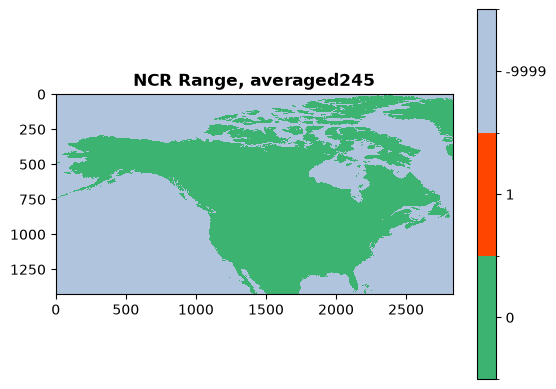

In [153]:
distr_rf_pred_245 = rasterio.open("outputs/prediction126_ensemble.tif").read(1)
plotit(distr_rf_pred_245, "NCR Range, averaged245", ["mediumseagreen", "orangered", "lightsteelblue"], cmap="Greens")

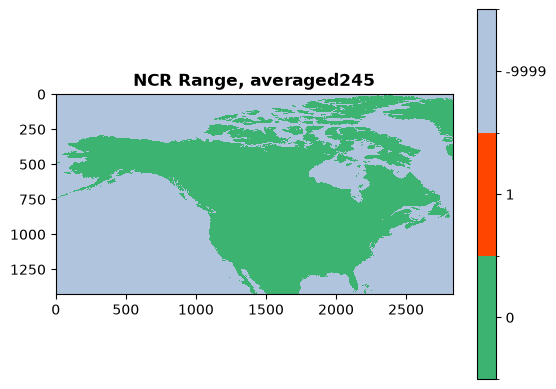

In [154]:
distr_rf_pred_245 = rasterio.open("outputs/prediction245_ensemble.tif").read(1)
plotit(distr_rf_pred_245, "NCR Range, averaged245", ["mediumseagreen", "orangered", "lightsteelblue"], cmap="Greens")

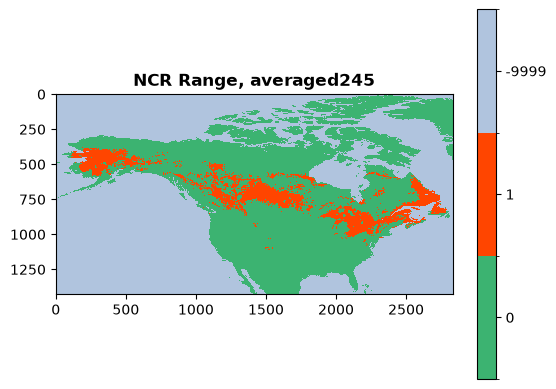

In [ ]:
distr_rf_pred_245 = rasterio.open("outputs/prediction370_ensemble.tif").read(1)
plotit(distr_rf_pred_245, "NCR Range, averaged245", ["mediumseagreen", "orangered", "lightsteelblue"], cmap="Greens")

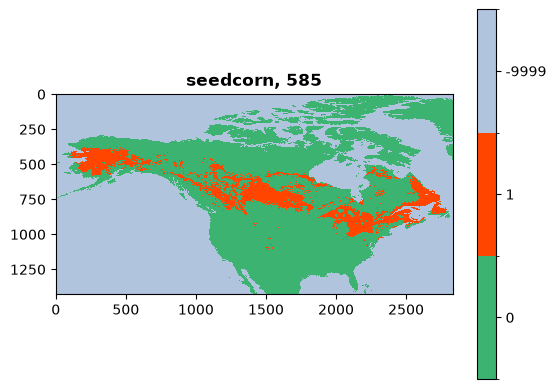

In [ ]:
distr_rf_pred_245 = rasterio.open("outputs/prediction585_ensemble.tif").read(1)
plotit(distr_rf_pred_245, command_ncr[3] + ', 585', ["mediumseagreen", "orangered", "lightsteelblue"], cmap="Greens")

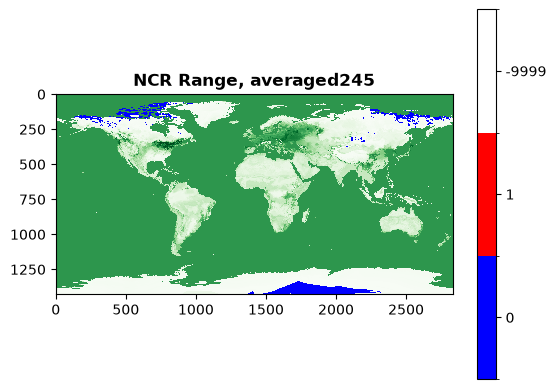

In [ ]:
distr_rf_245 = rasterio.open("outputs/rf1-images245/probability_1.0.tif").read(1)
plotit(distr_rf_245, "NCR Range, averaged245", ["blue", "red", "white"], cmap="Greens")



In [ ]:
distr

NameError: name 'distr' is not defined

C:\Users\chenst-intern\AppData\Local\Temp\ipykernel_22924\1587857658.py:1: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  distr_rf_126 = rasterio.open("outputs/rf1-images126/probability_1.0.tif").read(1)


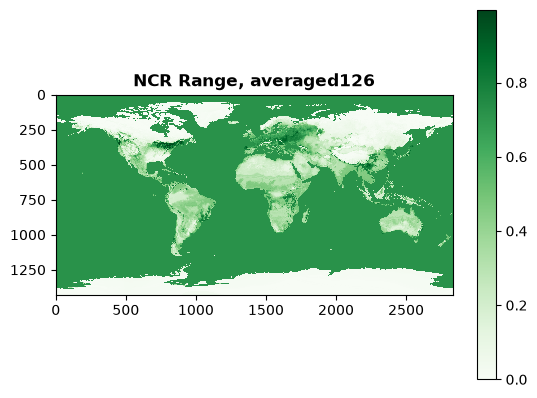

In [ ]:
distr_rf_126 = rasterio.open("outputs/rf1-images126/probability_1.0.tif").read(1)
plotit(distr_rf_126, "NCR Range, averaged126", cmap="Greens")

C:\Users\chenst-intern\AppData\Local\Temp\ipykernel_22924\2069586365.py:1: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  distr_rf_370 = rasterio.open("outputs/rf1-images370/probability_1.0.tif").read(1)


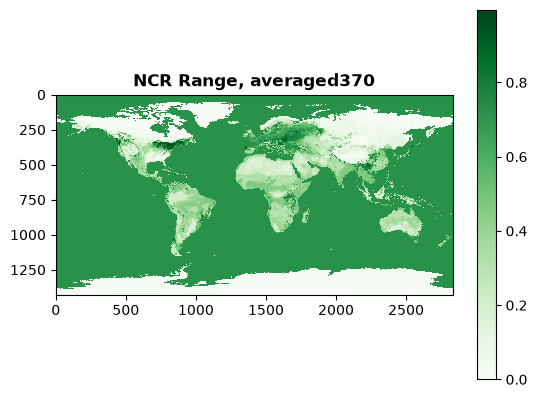

In [ ]:
distr_rf_370 = rasterio.open("outputs/rf1-images370/probability_1.0.tif").read(1)
plotit(distr_rf_370, "NCR Range, averaged370", cmap="Greens")

C:\Users\chenst-intern\AppData\Local\Temp\ipykernel_22924\143784660.py:1: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  distr_rf_585 = rasterio.open("outputs/rf1-images585/probability_1.0.tif").read(1)


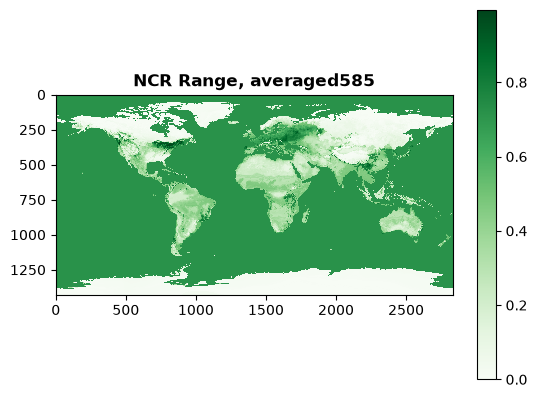

In [ ]:
distr_rf_585 = rasterio.open("outputs/rf1-images585/probability_1.0.tif").read(1)
plotit(distr_rf_585, "NCR Range, averaged585", cmap="Greens")

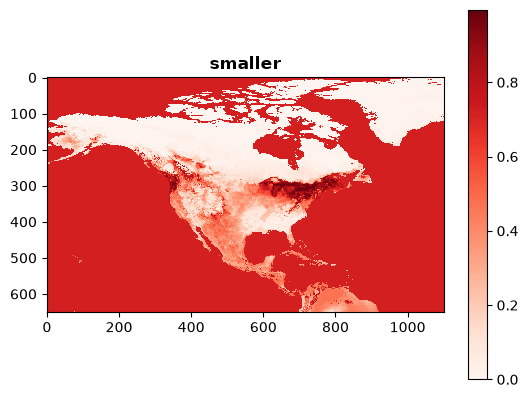

In [ ]:
plotit(distr_rf_585[50:700, 100:1200], "smaller", cmap="Reds")

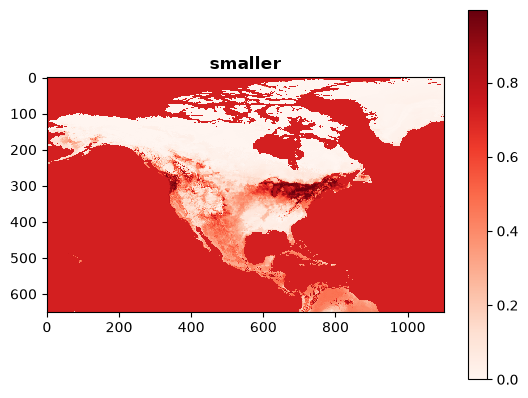

In [ ]:
plotit(distr_rf_126[50:700, 100:1200], "smaller", cmap="Reds")

In [ ]:
# THE ORDER IS SIGNIFICANT!!!!

print('There are ', len(future_ras_feats), ' raster features.')
print(future_ras_feats)
# current order: 13, 14, 15, 2, 4, 5, 6

There are  4  raster features.
[['future_split_bands_0\\future_bio13.tif', 'future_split_bands_0\\future_bio14.tif', 'future_split_bands_0\\future_bio15.tif', 'future_split_bands_0\\future_bio2.tif', 'future_split_bands_0\\future_bio4.tif', 'future_split_bands_0\\future_bio5.tif', 'future_split_bands_0\\future_bio6.tif'], ['future_split_bands_1\\future_bio13.tif', 'future_split_bands_1\\future_bio14.tif', 'future_split_bands_1\\future_bio15.tif', 'future_split_bands_1\\future_bio2.tif', 'future_split_bands_1\\future_bio4.tif', 'future_split_bands_1\\future_bio5.tif', 'future_split_bands_1\\future_bio6.tif'], ['future_split_bands_2\\future_bio13.tif', 'future_split_bands_2\\future_bio14.tif', 'future_split_bands_2\\future_bio15.tif', 'future_split_bands_2\\future_bio2.tif', 'future_split_bands_2\\future_bio4.tif', 'future_split_bands_2\\future_bio5.tif', 'future_split_bands_2\\future_bio6.tif'], ['future_split_bands_3\\future_bio13.tif', 'future_split_bands_3\\future_bio14.tif', 'future

In [ ]:
from pylab import plt
# define spatial plotter
def plotit(x, title, cmap="Blues"):
    plt.imshow(x, cmap=cmap, interpolation='nearest')
    plt.colorbar()
    plt.title(title, fontweight = 'bold')

distr_rf = rasterio.open("outputs/rf1-images/probability_1.0.tif").read(1)
plotit(distr_rf, "NCR Range, averaged", cmap="Greens")